<a href="dependencies/banner.jpeg">
      <img src="dependencies/banner.jpeg" alt="image0" width="100%">
</a>

# Single shot readout
This experiment is performed to calibrate single-shot readout for transmon qubits. The qubit is
prepared in either the |0⟩ or |1⟩ state, after which the resonator response is plotted in
the IQ plane. From the position of the two centroids a discriminator line is drawn that
can be used on the FPGA to classify single shots of the readout resonator into the |0⟩
and |1⟩ qubit states. Furthermore, the structure of the two centroids allows us to quantify
how well the two states can be distinguished and to find the State Preparation and Measurement (SPAM)
errors. This experiment allows the user to determine the appropriate acquisition rotation and threshold,
as described on the page documenting [readout](../../../products/architecture/sequencers/readout.md).

In [1]:
from dependencies.analysis_utils import SSROAnalysis
from xarray import open_dataset

from qblox_scheduler import HardwareAgent, Schedule
from qblox_scheduler.operations import Measure, Reset, X
from qblox_scheduler.operations.expressions import DType
from qblox_scheduler.operations.loop_domains import arange

Generating hash table for SingleQubitClifford.
Hash table generated.
Generating hash table for TwoQubitCliffordCZ.


Hash table generated.
Generating hash table for TwoQubitCliffordZX.


Hash table generated.


/.venv/lib/python3.14/site-packages/quantify_core/visualization/instrument_monitor.py:13: QCoDeSDeprecationWarning: The `qcodes.utils.helpers` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.utils.helpers import strip_attrs


## Setup
The hardware agent manages the connection to the instrument and ensures that pulses and acquisitions happen over the appropriate input and output channels of the Cluster.
The cell below creates an instance of the `HardwareAgent` based on the hardware- and device-under-test configuration files in the `./dependencies/configs` folder, allowing us to start doing measurements.
We also define some convenient aliases to use throughout our measurements.
For a more thorough discussion of the hardware- and device-under-test configuration files, check out [this tutorial](000_transmon_setup.ipynb).

In [2]:
# Set up hardware agent, this automatically connects to the instrument
hw_agent = HardwareAgent(
    hardware_configuration="./dependencies/configs/hw_config.json",
    quantum_device_configuration="./dependencies/configs/dut_config.json",
)

# convenience aliases
q0 = hw_agent.quantum_device.get_element("q0")  # Qubits 0 and 2 are measured using QRM-RF + QCM-RF
q2 = hw_agent.quantum_device.get_element("q2")
q3 = hw_agent.quantum_device.get_element("q3")  # Qubit 3 is measured using QRC

cluster = hw_agent.get_clusters()["cluster"]
hw_options = hw_agent.hardware_configuration.hardware_options
qubit = q0

/.venv/lib/python3.14/site-packages/qblox_scheduler/qblox/hardware_agent.py:556: UserWarning: cluster: Trying to instantiate cluster with ip 'None'.Creating a dummy cluster.
  warnings.warn(


## Experiment settings

In [3]:
num_shots = 1000

## Experiment schedule

In [4]:
ssro_sched = Schedule("Readout")

with ssro_sched.loop(arange(start=0, stop=num_shots, step=1, dtype=DType.NUMBER)) as rep:
    ssro_sched.add(Reset(qubit.name))
    # Measure |0>
    ssro_sched.add(Measure(qubit.name, coords={"reps": rep, "state": 0}, acq_channel="S_21"))
    # Prepare |1>
    ssro_sched.add(Reset(qubit.name))
    ssro_sched.add(X(qubit=qubit.name))
    # Measure |1>
    ssro_sched.add(Measure(qubit.name, coords={"reps": rep, "state": 1}, acq_channel="S_21"))

# Execute the experiment
ssro_data = hw_agent.run(ssro_sched)
if cluster.is_dummy:
    example_data = open_dataset(
        "./dependencies/datasets/single_shot_readout.hdf5", engine="h5netcdf"
    )
    ssro_data = ssro_data.update({"S_21": example_data.S_21})

## Analyze the experiment

findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


...

findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


findfont: Failed to find font weight 300, now using 400.


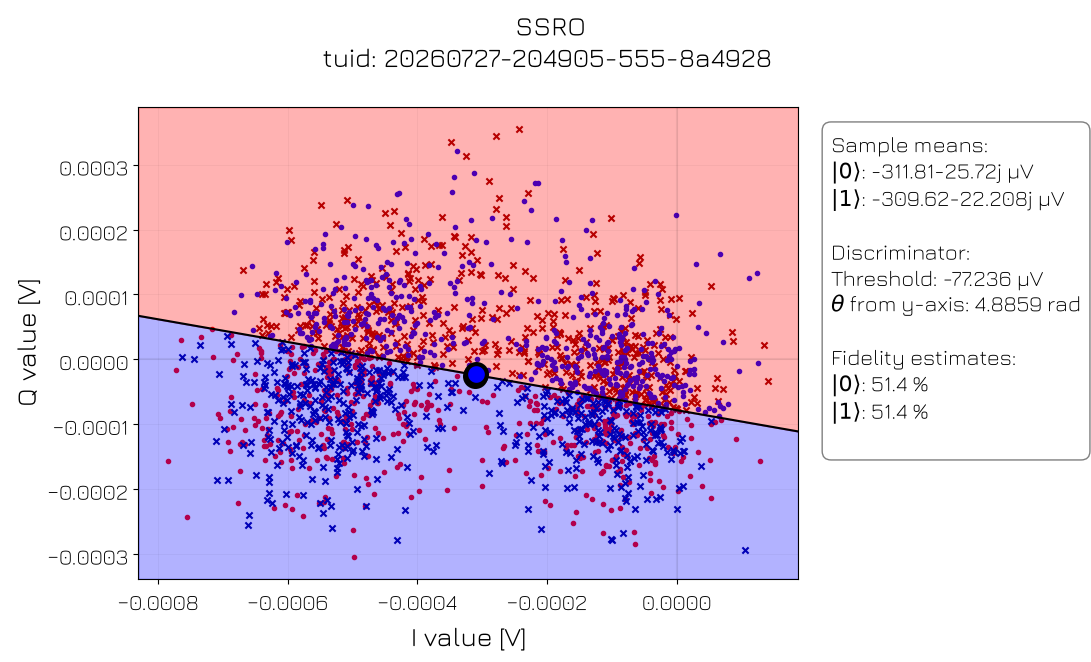

In [5]:
ssro_analysis = SSROAnalysis(ssro_data).run()
ssro_analysis.display_figs_mpl()

## Post-run

In [6]:
# Update device config
qubit.measure.acq_rotation = ssro_analysis.quantities_of_interest["acq_rotation_rad"].nominal_value
qubit.measure.acq_threshold = ssro_analysis.quantities_of_interest["acq_threshold"].nominal_value

#### Update the device configuration file
After measurement, we may store the measured device properties inside a new file to use in future experiments.
The time-unique identifier ensures that it is easy to find back previously found measurement results.

In [7]:
hw_agent.quantum_device.to_json_file("./dependencies/configs", add_timestamp=True)

'./dependencies/configs/two_flux_tunable_transmons_2026-07-27_20-49-06_UTC.json'